<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/Ipynb/DataAnalysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

In [2]:
# 파일 리스트 (본인의 파일명에 맞게 수정)
file_names = ['P1_Exp1_AbsoluteThresholdDetection.csv','P2_Exp1_AbsoluteThresholdDetection.csv','P3_Exp1_AbsoluteThresholdDetection.csv','P4_Exp1_AbsoluteThresholdDetection.csv'
              ,'P5_Exp1_AbsoluteThresholdDetection.csv', 'P6_Exp1_AbsoluteThresholdDetection.csv']
data_list = []

for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"no: {file}")

# 데이터 통합
if data_list:
    df = pd.concat(data_list, ignore_index=True)

    # 1. Condition 명칭 변경 (Active -> On-touch)
    df['Condition'] = df['Condition'].replace('Active', 'On-touch(Soft)')

    # 2. 분석 대상 구역 필터링 (Area A, B, C)
    df = df[df['Area'].isin(['A', 'B', 'C'])]

    # 3. Force 문자열에서 숫자만 추출 (예: '0.07g' -> 0.07)
    df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)

    print("완")
else:
    print("없")

완


<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_152/3873148505.py:24: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


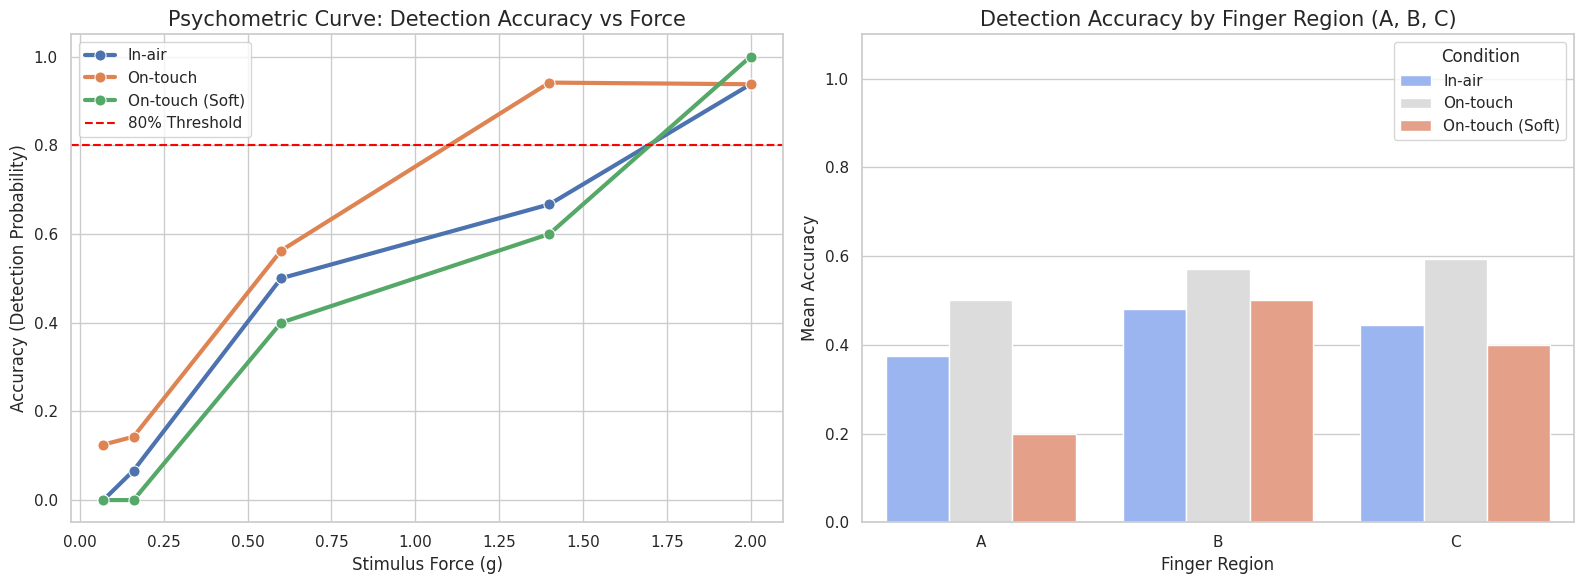

In [3]:
# 1. 전반적인 강도별 정답률 계산 (Psychometric Curve용)
overall_acc = df.groupby(['Condition', 'Force_Val'])['IsCorrect'].mean().reset_index()

# 2. 구역별(Area) 평균 정답률 계산 (Bar Chart용)
area_acc = df.groupby(['Condition', 'Area'])['IsCorrect'].mean().reset_index()

# 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (Left) Psychometric Curve
sns.lineplot(ax=axes[0], data=overall_acc, x='Force_Val', y='IsCorrect',
             hue='Condition', marker='o', linewidth=3, markersize=8)
axes[0].axhline(0.8, color='red', linestyle='--', label='80% Threshold')
axes[0].set_title('Psychometric Curve: Detection Accuracy vs Force', fontsize=15)
axes[0].set_xlabel('Stimulus Force (g)', fontsize=12)
axes[0].set_ylabel('Accuracy (Detection Probability)', fontsize=12)
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

# (Right) Regional Accuracy
sns.barplot(ax=axes[1], data=area_acc, x='Area', y='IsCorrect',
            hue='Condition', order=['A', 'B', 'C'], palette='coolwarm')
axes[1].set_title('Detection Accuracy by Finger Region (A, B, C)', fontsize=15)
axes[1].set_xlabel('Finger Region', fontsize=12)
axes[1].set_ylabel('Mean Accuracy', fontsize=12)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

##Binary based boxplt and scatter

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_152/197754908.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)
/tmp/ipykernel_152/197754908.py:20: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
/tmp/ipykernel_152/197754908.py:28: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


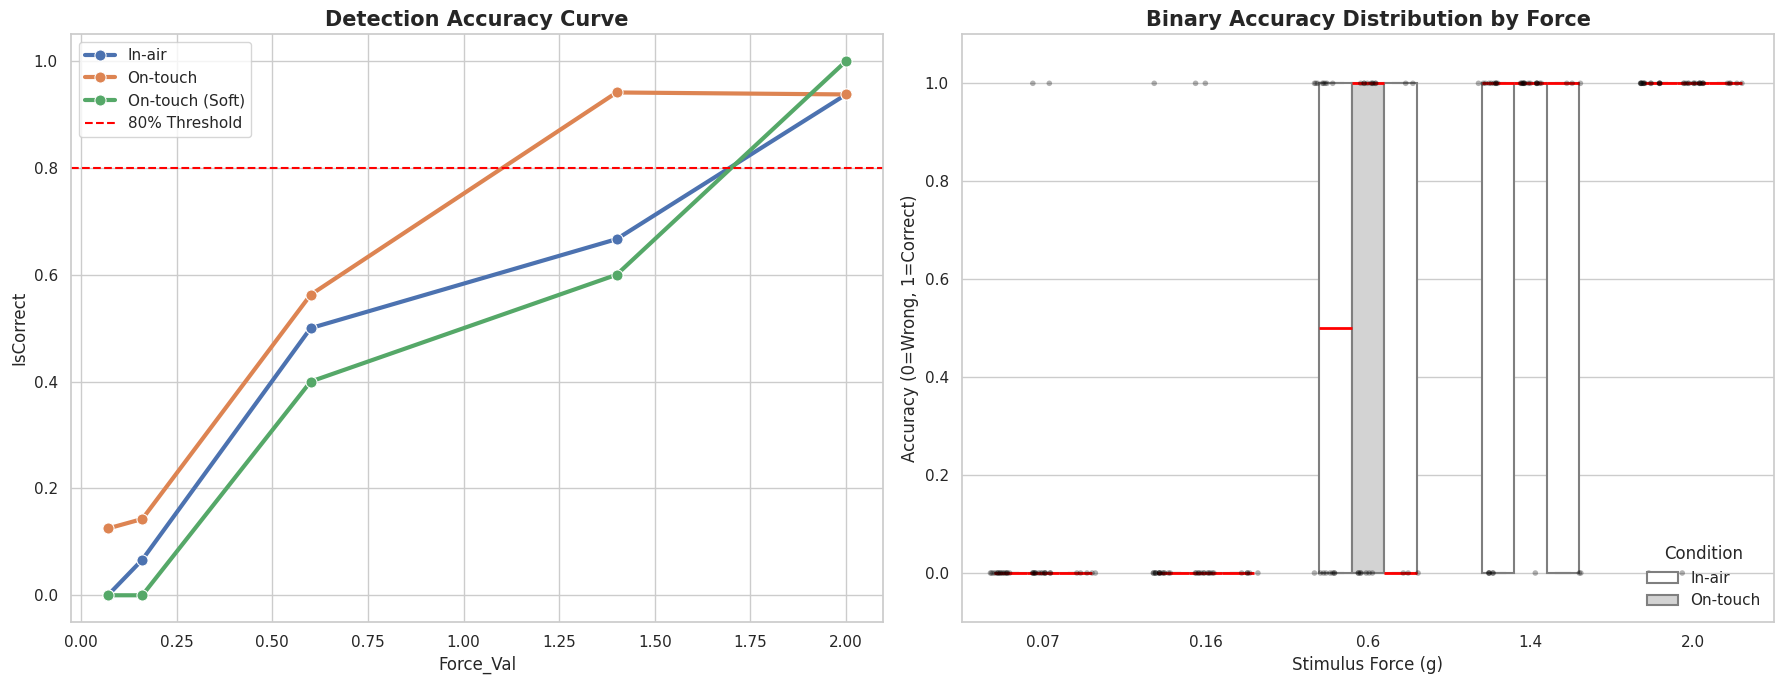

In [4]:
df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)
df['Condition'] = df['Condition'].replace('Active', 'On-touch')
force_order = sorted(df['Force_Val'].unique())

# 2. 그래프 그리기 (1x2 Plot)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="white")

# --- (Left) Psychometric Curve (전체 평균) ---
overall_acc = df.groupby(['Condition', 'Force_Val'])['IsCorrect'].mean().reset_index()
sns.lineplot(ax=axes[0], data=overall_acc, x='Force_Val', y='IsCorrect',
             hue='Condition', marker='o', linewidth=3, markersize=8)
axes[0].axhline(0.8, color='red', linestyle='--', label='80% Threshold')
axes[0].set_title('Detection Accuracy Curve', fontsize=15, fontweight='bold')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

# --- (Right) Binary Accuracy Box Plot by Force ---
# y축이 IsCorrect(0 또는 1)인 상태에서 강도별 분포 확인
sns.boxplot(
    ax=axes[1], data=df, x='Force_Val', y='IsCorrect', hue='Condition',
    order=force_order, palette=['#FFFFFF', '#D3D3D3'],
    linewidth=1.5, fliersize=0, width=0.6,
    medianprops={'color': 'red', 'linewidth': 2}  # 중앙값 빨간 선
)

# 개별 응답(0 또는 1)을 점으로 표시
sns.stripplot(
    ax=axes[1], data=df, x='Force_Val', y='IsCorrect', hue='Condition',
    order=force_order, dodge=True, palette=['#000000', '#000000'],
    alpha=0.3, size=4, jitter=0.2
)

axes[1].set_title('Binary Accuracy Distribution by Force', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Stimulus Force (g)', fontsize=12)
axes[1].set_ylabel('Accuracy (0=Wrong, 1=Correct)', fontsize=12)
axes[1].set_ylim(-0.1, 1.1)

# 레전드 정리
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[0:2], labels[0:2], title='Condition', frameon=False, loc='lower right')

plt.tight_layout()
plt.show()

In [5]:
print("="*40)
print("       [SUMMARY STATISTICS]       ")
print("="*40)

# 역치 산출 (정답률 80% 기준 최소 강도)
print("\n1. Estimated Absolute Thresholds (80% Accuracy):")
for cond in overall_acc['Condition'].unique():
    cond_df = overall_acc[overall_acc['Condition'] == cond]
    threshold_df = cond_df[cond_df['IsCorrect'] >= 0.8]

    if not threshold_df.empty:
        threshold = threshold_df['Force_Val'].min()
        print(f" - {cond}: {threshold}g")
    else:
        print(f" - {cond}: 80% 정답률에 도달하지 못함")

# 구역별 상세 정답률 출력
print("\n2. Regional Accuracy Table:")
pivot_area = area_acc.pivot(index='Area', columns='Condition', values='IsCorrect')
print(pivot_area)

# 강도별 상세 정답률 출력
print("\n3. Force-wise Accuracy Table:")
pivot_force = overall_acc.pivot(index='Force_Val', columns='Condition', values='IsCorrect')
print(pivot_force)

       [SUMMARY STATISTICS]       

1. Estimated Absolute Thresholds (80% Accuracy):
 - In-air: 2.0g
 - On-touch: 1.4g
 - On-touch (Soft): 2.0g

2. Regional Accuracy Table:
Condition    In-air  On-touch  On-touch (Soft)
Area                                          
A          0.375000  0.500000              0.2
B          0.481481  0.571429              0.5
C          0.444444  0.592593              0.4

3. Force-wise Accuracy Table:
Condition    In-air  On-touch  On-touch (Soft)
Force_Val                                     
0.07       0.000000  0.125000              0.0
0.16       0.066667  0.142857              0.0
0.60       0.500000  0.562500              0.4
1.40       0.666667  0.941176              0.6
2.00       0.937500  0.937500              1.0


##relative accuracy || error based score

In [6]:
for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"no: {file}")

# 데이터 통합
if data_list:
    df = pd.concat(data_list, ignore_index=True)

    # 1. Condition 명칭 변경 (Active -> On-touch)
    df['Condition'] = df['Condition'].replace('Active', 'On-touch')

    # 2. 분석 대상 구역 필터링 (Area A, B, C)
    #df = df[df['Area'].isin(['A', 'B', 'C'])]

    # 3. Force 문자열에서 숫자만 추출 (예: '0.07g' -> 0.07)
    df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)

    print("완")
else:
    print("없")

완


<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_152/1978903883.py:19: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


##Relative Accuracy | Target이 분모

/tmp/ipykernel_152/799540335.py:23: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(
/tmp/ipykernel_152/799540335.py:30: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


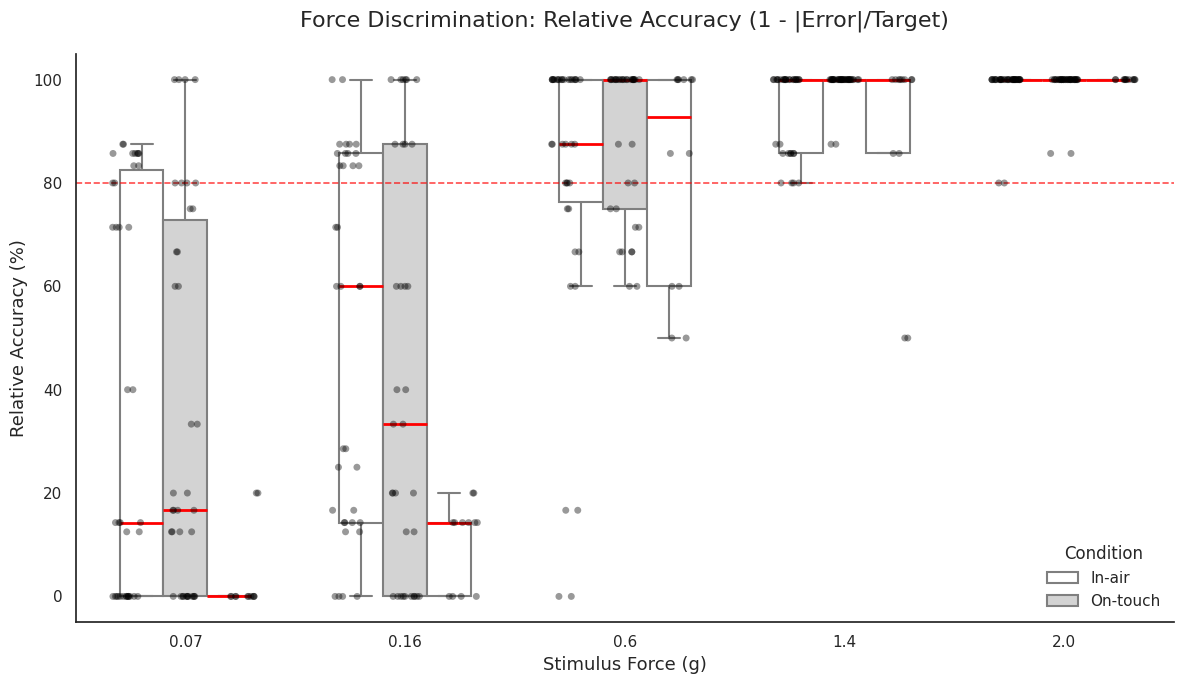

In [7]:
# 2. 새로운 Relative Accuracy 계산 (Target 대비 오차 비율 반영)
def calc_relative_accuracy(row):
    # Target이 0인 경우(분모가 0이 되는 경우) 방지
    if row['Target'] == 0:
        return 100 if row['Response'] == 0 else 0

    # Target 대비 절대 오차 비율 계산: |Target - Response| / Target
    error_ratio = abs(row['Target'] - row['Response']) / row['Target']

    # 정확도 계산: (1 - 오차비율) * 100
    score = (1 - error_ratio) * 100

    # 점수가 음수가 되지 않도록 하한선(0) 적용
    return max(0, score)

df['Relative_Score'] = df.apply(calc_relative_accuracy, axis=1)

# 3. 시각화 (동일한 스타일 유지)
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")
force_order = sorted(df['Force_Val'].unique())

ax = sns.boxplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    palette=['#FFFFFF', '#D3D3D3'],
    linewidth=1.5, fliersize=0, width=0.6, order=force_order,
    medianprops={'color': 'red', 'linewidth': 2}
)

sns.stripplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    dodge=True, palette=['#000000', '#000000'],
    alpha=0.4, size=5, jitter=0.2, ax=ax, order=force_order
)

# 80% 성능 가이드라인
plt.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

plt.title('Force Discrimination: Relative Accuracy (1 - |Error|/Target)', fontsize=16, pad=20)
plt.xlabel('Stimulus Force (g)', fontsize=13)
plt.ylabel('Relative Accuracy (%)', fontsize=13)
plt.ylim(-5, 105)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Condition', frameon=False, loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_152/2074664361.py:19: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(
/tmp/ipykernel_152/2074664361.py:26: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


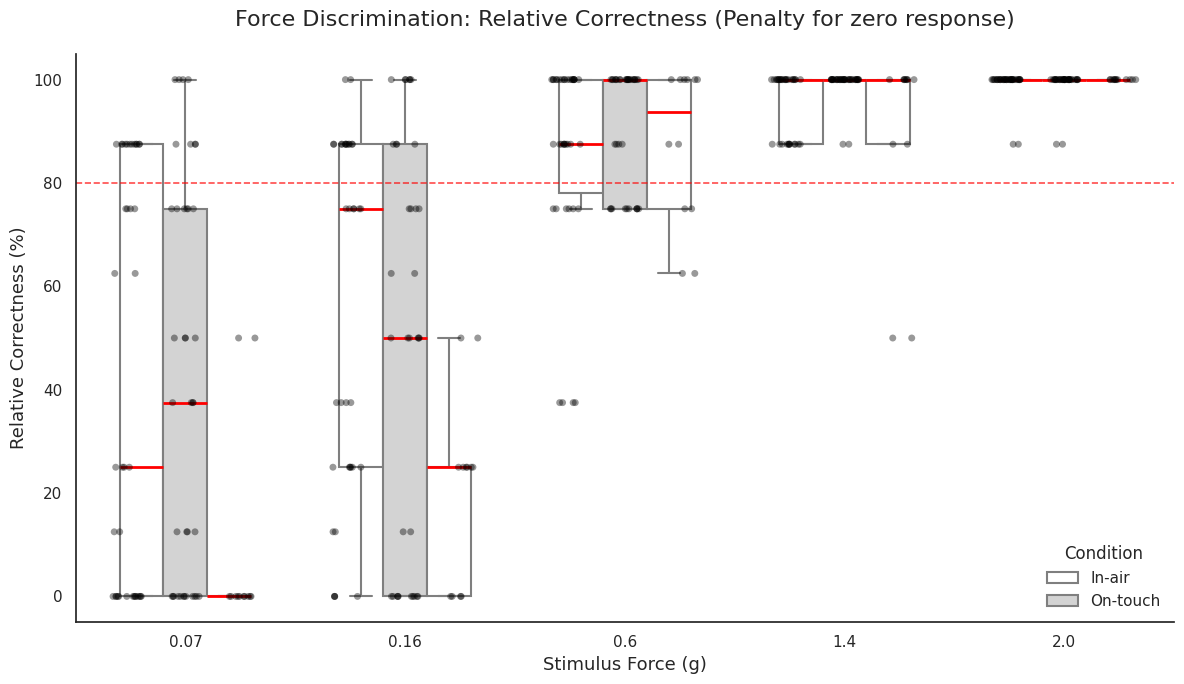

In [8]:
# 2. 수정된 Relative Score 계산 (응답 0일 경우 무조건 0점)
def calc_relative_score(row):
    # 피험자가 0번이라고 답한 경우 (인지 실패) -> 무조건 0점
    if row['Response'] == 0:
        return 0

    # 그 외의 경우: 오차 1회당 10점씩 감점 (최소 0점)
    error = abs(row['Target'] - row['Response'])
    score = 100 - (error * 12.5)
    return max(0, score)

df['Relative_Score'] = df.apply(calc_relative_score, axis=1)

# 3. 시각화
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")
force_order = sorted(df['Force_Val'].unique())

ax = sns.boxplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    palette=['#FFFFFF', '#D3D3D3'],
    linewidth=1.5, fliersize=0, width=0.6, order=force_order,
    medianprops={'color': 'red', 'linewidth': 2}
)

sns.stripplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    dodge=True, palette=['#000000', '#000000'],
    alpha=0.4, size=5, jitter=0.2, ax=ax, order=force_order
)

plt.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
plt.title('Force Discrimination: Relative Correctness (Penalty for zero response)', fontsize=16, pad=20)
plt.xlabel('Stimulus Force (g)', fontsize=13)
plt.ylabel('Relative Correctness (%)', fontsize=13)
plt.ylim(-5, 105)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Condition', frameon=False, loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

##Region별 accuracy

In [9]:
# 1. 파일 리스트 (본인의 CSV 파일명으로 수정)
file_names = ['P1_Exp1_AbsoluteThresholdDetection.csv','P2_Exp1_AbsoluteThresholdDetection.csv','P3_Exp1_AbsoluteThresholdDetection.csv','P4_Exp1_AbsoluteThresholdDetection.csv'
              ,'P5_Exp1_AbsoluteThresholdDetection.csv', 'P6_Exp1_AbsoluteThresholdDetection.csv']
data_list = []

for f in file_names:
    try:
        temp = pd.read_csv(f)
        df_list.append(temp)
    except FileNotFoundError:
        print(f"⚠️ 파일을 찾을 수 없음: {f}")

# 2. 데이터 통합 및 클리닝
df = pd.concat(df_list, ignore_index=True)
df['Condition'] = df['Condition'].replace('Active', 'On-touch')
df = df[df['Area'].isin(['A', 'B', 'C'])]
# '0.07g' 문자열에서 숫자만 추출
df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)

# 3. 구역별/강도별 정답률 계산 (Dilution 방지 핵심)
region_acc = df.groupby(['Condition', 'Area', 'Force_Val'])['IsCorrect'].mean().reset_index()

print("✅ 데이터 전처리 및 Region별 그룹화 완료")

⚠️ 파일을 찾을 수 없음: Tactile_S01.csv
⚠️ 파일을 찾을 수 없음: Tactile_S02.csv
⚠️ 파일을 찾을 수 없음: Tactile_S03.csv
⚠️ 파일을 찾을 수 없음: Tactile_S04.csv


<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_152/3903644341.py:17: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


ValueError: No objects to concatenate

In [ ]:
# In-air와 On-touch를 비교하기 위한 1x2 서브플롯
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

conditions = ['In-air', 'On-touch']
# 구역별 색상 고정 (A: 청색, B: 황색, C: 녹색)
colors = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#2ca02c"}

for i, cond in enumerate(conditions):
    cond_data = region_acc[region_acc['Condition'] == cond]

    # Area별로 선을 따로 그림
    sns.lineplot(
        ax=axes[i],
        data=cond_data,
        x='Force_Val',
        y='IsCorrect',
        hue='Area',
        hue_order=['A', 'B', 'C'],
        palette=colors,
        marker='o',
        linewidth=3,
        markersize=9
    )

    # 기준선 추가 (80% 역치 및 50% 찍기 수준)
    axes[i].axhline(0.8, color='red', linestyle='--', alpha=0.6, label='80% Threshold')
    axes[i].axhline(0.5, color='black', linestyle=':', alpha=0.8, label='Chance Level (0.5)')

    axes[i].set_title(f'Detection Sensitivity by Area: {cond}', fontsize=18, fontweight='bold')
    axes[i].set_xlabel('Stimulus Force (g)', fontsize=13)
    axes[i].set_ylabel('Accuracy', fontsize=13)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(title="Finger Region", fontsize=11)

plt.tight_layout()
plt.show()

##Box Plot for Region

<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_152/4251543323.py:21: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


발견된 파일: ['P2_Exp1_AbsoluteThresholdDetection.csv', 'P4_Exp1_AbsoluteThresholdDetection.csv', 'P3_Exp1_AbsoluteThresholdDetection.csv', 'P1_Exp1_AbsoluteThresholdDetection.csv', 'P6_Exp1_AbsoluteThresholdDetection.csv', 'P5_Exp1_AbsoluteThresholdDetection.csv']


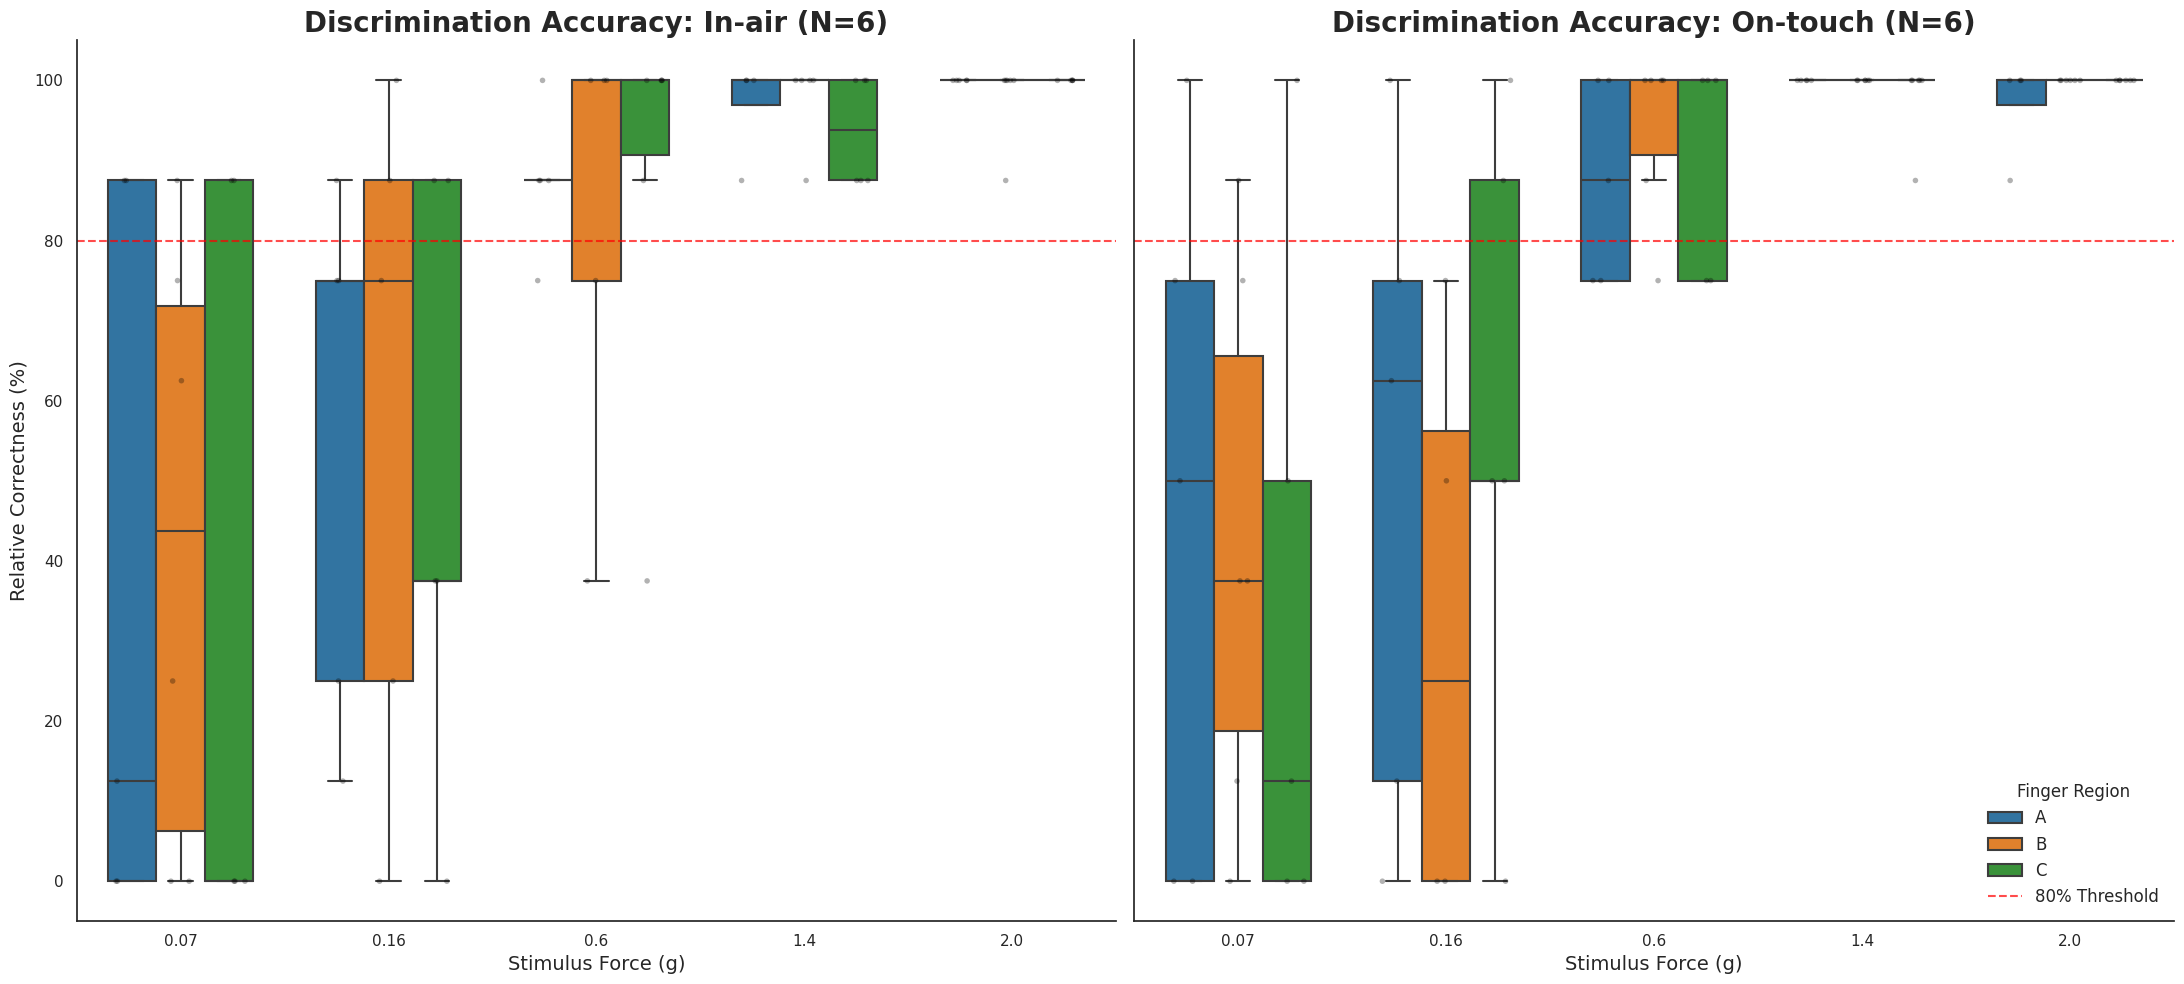

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# 1. 모든 Tactile_S*.csv 파일 자동 로드 및 통합
file_pattern = 'P*_Exp1_AbsoluteThresholdDetection.csv'
all_files = glob.glob(file_pattern)

if not all_files:
    print("분석할 CSV 파일을 찾을 수 없습니다.")
else:
    print(f"발견된 파일: {all_files}")
    df_list = [pd.read_csv(f) for f in all_files]
    df = pd.concat(df_list, ignore_index=True)

    # 2. 데이터 전처리
    # Force 값 추출 (예: '0.6g' -> 0.6)
    df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)
    # Condition 명칭 통일
    df['Condition'] = df['Condition'].replace('Active', 'On-touch')

    # 3. 12.5% 페널티 로직 적용 (최대 8회 기준, 응답 0이면 0점)
    def calc_relative_score(row):
        if row['Response'] == 0:
            return 0
        error = abs(row['Target'] - row['Response'])
        # 최대 8회 기준: 100 / 8 = 12.5% 페널티
        score = 100 - (error * 12.5)
        return max(0, score)

    df['Relative_Score'] = df.apply(calc_relative_score, axis=1)

    # 4. 시각화 (1x2 Subplots: In-air vs On-touch)
    fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
    sns.set_theme(style="white")

    conditions = ['In-air', 'On-touch']
    colors = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#2ca02c"} # 요청하신 구역 색상
    force_order = sorted(df['Force_Val'].unique())

    for i, cond in enumerate(conditions):
        cond_data = df[df['Condition'] == cond]

        # Box Plot: x축은 Force, hue는 Area
        sns.boxplot(
            ax=axes[i],
            data=cond_data,
            x='Force_Val',
            y='Relative_Score',
            hue='Area',
            hue_order=['A', 'B', 'C'],
            palette=colors,
            width=0.7,
            linewidth=1.5,
            fliersize=0,
            order=force_order
        )

        # Scatter Point (Strip plot) 겹치기 (개별 피험자 데이터 점)
        sns.stripplot(
            ax=axes[i],
            data=cond_data,
            x='Force_Val',
            y='Relative_Score',
            hue='Area',
            hue_order=['A', 'B', 'C'],
            dodge=True,
            palette=['#000000']*3, # 시인성을 위해 검은색 점 사용
            alpha=0.3,
            size=4,
            jitter=0.15,
            order=force_order,
            legend=False
        )

        # 80% 역치 기준선
        axes[i].axhline(80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Threshold')

        # 타이틀 및 라벨 설정 (N수 자동 표시)
        num_subjects = df['SubjectID'].nunique()
        axes[i].set_title(f'Discrimination Accuracy: {cond} (N={num_subjects})', fontsize=20, fontweight='bold')
        axes[i].set_xlabel('Stimulus Force (g)', fontsize=14)
        axes[i].set_ylabel('Relative Correctness (%)' if i==0 else "", fontsize=14)
        axes[i].set_ylim(-5, 105)

        # 레전드 설정
        if i == 1:
            axes[i].legend(title="Finger Region", loc='lower right', frameon=False, fontsize=12)
        else:
            if axes[i].get_legend():
                axes[i].get_legend().remove()

    sns.despine()
    plt.tight_layout()
    plt.show()

In [11]:
print("="*50)
print(" [각 조건/구역별 80% 정답률 도달 Force (g)] ")
print("="*50)

# 정답률이 0.8 이상인 데이터 중 가장 작은 Force 값을 찾음
thresholds = region_acc[region_acc['IsCorrect'] >= 0.8].groupby(['Condition', 'Area'])['Force_Val'].min().reset_index()

# 보기 좋게 피벗 테이블로 출력
pivot_thresholds = thresholds.pivot(index='Area', columns='Condition', values='Force_Val')
print(pivot_thresholds)

print("\n💡 해석 팁: 값이 작을수록 더 낮은 힘에서 자극을 감지했다는 뜻임.")

 [각 조건/구역별 80% 정답률 도달 Force (g)] 


NameError: name 'region_acc' is not defined

In [ ]:
# 각 조건/구역별로 정확히 80%를 넘는 최소 Force 값을 찾는 코드
thresholds = region_acc[region_acc['IsCorrect'] >= 0.8].groupby(['Condition', 'Area'])['Force_Val'].min()
print(thresholds)